In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('housing.csv')

In [3]:
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
data.shape

(545, 13)

In [5]:
print(data.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [6]:
target = "price"

features = data.columns.drop("price")

print("Target variables: ",target)
print("Feature variables:")
print(features)

Target variables:  price
Feature variables:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [7]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
print("Analysis: No missing value found")

Analysis: No missing value found


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
print("Analysis: No duplicate rows found")

Analysis: No duplicate rows found


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [12]:
# We need to convert all the values of obejcts into numerical values for further processing
# Will do it using one-hot encoding

data = pd.get_dummies(data, drop_first = True)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [14]:
data.shape

(545, 14)

In [15]:
data.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [16]:
### Feature Selection

#The dataset was examined for irrelevant attributes.

#All available features were retained because they represent important property characteristics that can influence house prices, such as area, number of bedrooms, bathrooms, parking availability, furnishing status, and other amenities.

#Therefore, no feature columns were removed.

In [17]:
### Linear Regression

# Features (Independent Variables)
X = data.drop("price", axis=1)

# Target Variable (Dependent Variable)
y = data["price"]

In [18]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes of split datasets
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (436, 13)
X_test Shape : (109, 13)
y_train Shape: (436,)
y_test Shape : (109,)


In [19]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model using training data
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [20]:
# Predict prices for test dataset
lr_pred = lr_model.predict(X_test)

# Display first 10 predicted values
print("First 10 Predictions:")
print(lr_pred[:10])

First 10 Predictions:
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [21]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Calculate evaluation metrics

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5

lr_r2 = r2_score(y_test, lr_pred)

# Display results

print("Linear Regression Performance")
print("-----------------------------")
print("MAE  :", lr_mae)
print("RMSE :", lr_rmse)
print("R²   :", lr_r2)

Linear Regression Performance
-----------------------------
MAE  : 970043.4039201635
RMSE : 1324506.9600914384
R²   : 0.6529242642153186


In [22]:
### RANDOM FOREST

In [37]:
# Import Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train Model

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [38]:
# Predict prices using Random Forest

rf_pred = rf_model.predict(X_test)

# Display first 10 predictions

print("First 10 Random Forest Predictions:")
print(rf_pred[:10])

First 10 Random Forest Predictions:
[5433085.    7194355.    3779741.875 4536595.    3659967.5   3468290.
 5065305.    5150705.    2573830.    2910027.75 ]


In [39]:
# Import evaluation metrics

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Calculate metrics

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

# Display results

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Performance
-------------------------
MAE : 1013968.579587156
RMSE: 1398115.6668385956
R²  : 0.6132752494107068


In [40]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


In [42]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance (%)": rf_model.feature_importances_ * 100
})

importance = importance.sort_values(
    by="Importance (%)",
    ascending=False
)

print(importance)

                            Feature  Importance (%)
0                              area       46.853511
2                         bathrooms       15.255406
9               airconditioning_yes        6.023804
4                           parking        5.727261
3                           stories        5.706352
1                          bedrooms        4.736976
12     furnishingstatus_unfurnished        3.697178
7                      basement_yes        3.217611
10                     prefarea_yes        2.843226
8               hotwaterheating_yes        1.830547
6                     guestroom_yes        1.780510
11  furnishingstatus_semi-furnished        1.323714
5                      mainroad_yes        1.003903


In [43]:
### PLOTS

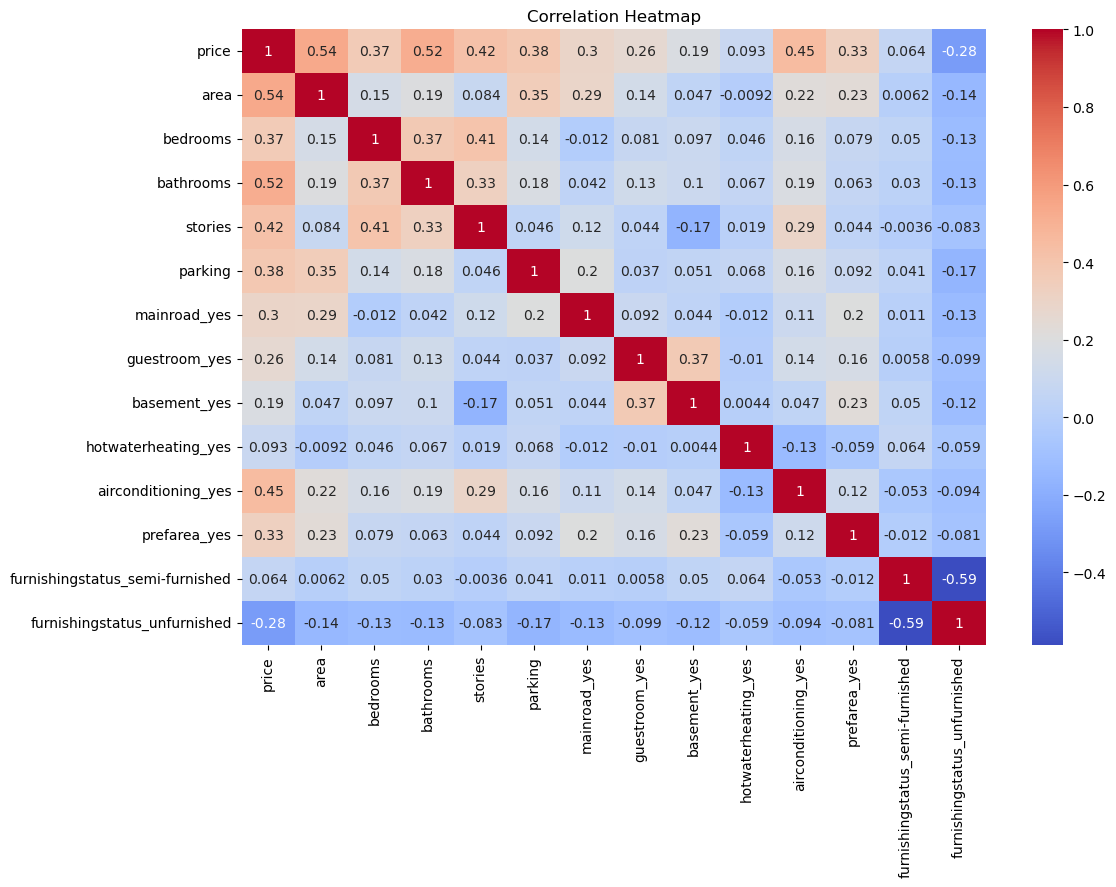

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [46]:
### CONCLUSION: Area and Bathrooms show strong positive correlation with Price

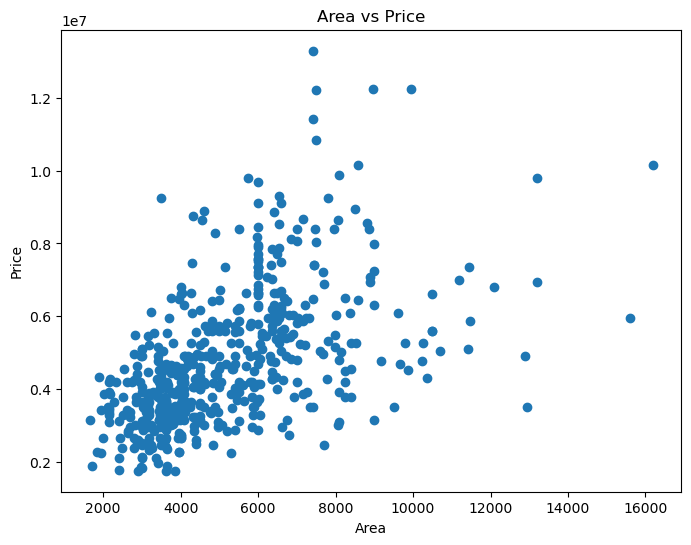

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    data["area"],
    data["price"]
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

In [48]:
### CONCLUSION: House prices generally increase with area.

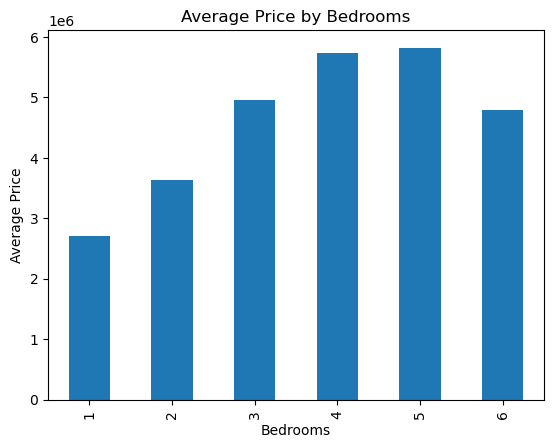

In [49]:
bedroom_price = data.groupby(
    "bedrooms"
)["price"].mean()

bedroom_price.plot(
    kind="bar"
)

plt.title("Average Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")

plt.show()

In [50]:
### CONCLUSION: Houses with more bedrooms tend to have higher prices.

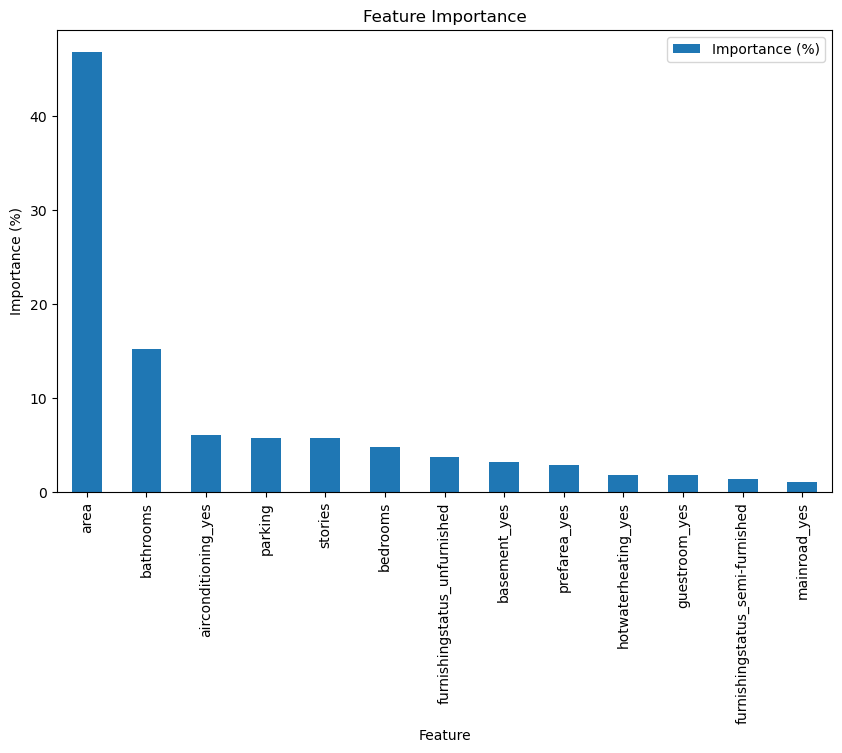

In [51]:
importance.plot(
    x="Feature",
    y="Importance (%)",
    kind="bar",
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.ylabel("Importance (%)")
plt.show()

In [52]:
### CONCLUSION: Area contributes approximately 47% of the predictive power of the model and is the most influential feature.

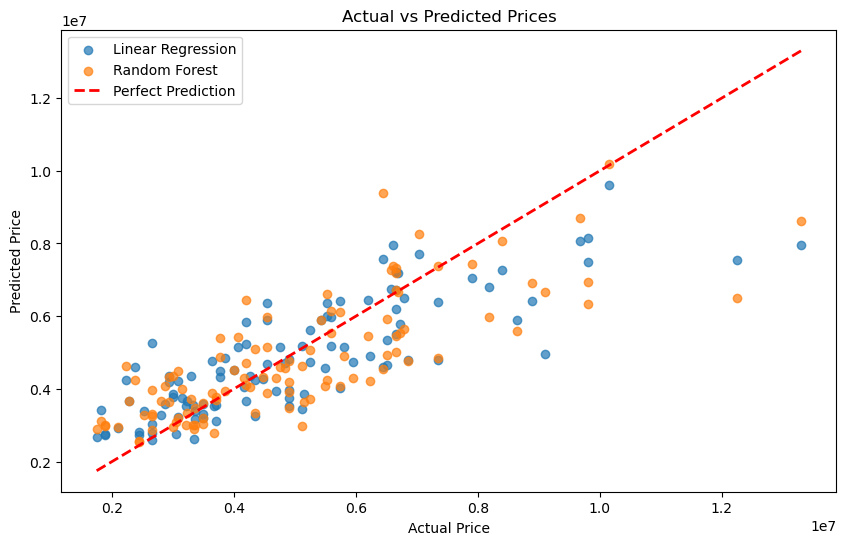

In [57]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.7,
    label="Linear Regression"
)

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7,
    label="Random Forest"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.legend()

plt.show()

In [58]:
### CONCLUSION: Linear Regression predictions are more closely aligned with the ideal prediction line than Random Forest predictions, indicating better overall performance in predicting house prices.

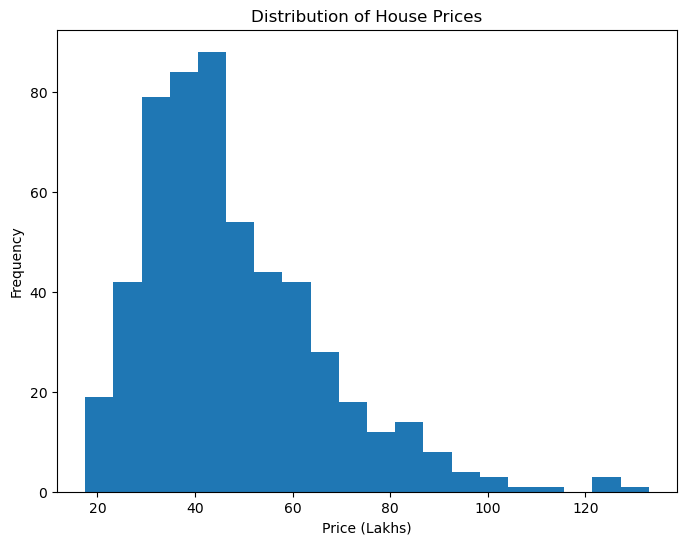

In [60]:
plt.figure(figsize=(8,6))

plt.hist(data["price"]/100000, bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")

plt.show()

In [61]:
### CONCLUSION: Most houses in the dataset are priced between ₹30 lakh and ₹60 lakh, while only a few houses have prices above ₹1 crore, indicating a right-skewed distribution.

In [62]:
print("="*50)
print("HOUSE PRICE PREDICTION PROJECT SUMMARY")
print("="*50)

print("\nBest Model: Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

print("\nMost Important Features:")
print(importance.head(5))

HOUSE PRICE PREDICTION PROJECT SUMMARY

Best Model: Linear Regression
MAE : 970043.4039201635
RMSE: 1324506.9600914384
R²  : 0.6529242642153186

Most Important Features:
               Feature  Importance (%)
0                 area       46.853511
2            bathrooms       15.255406
9  airconditioning_yes        6.023804
4              parking        5.727261
3              stories        5.706352
